**Imports libraries**

In [1]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.utils import resample

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported.")


Libraries imported.


**Load train and test from SQLite**

In [2]:
DB_PATH = "Assignment2025S2.sqlite"  # Make sure file is in root

with sqlite3.connect(DB_PATH) as conn:
    train_df = pd.read_sql("SELECT * FROM train", conn)
    test_df  = pd.read_sql("SELECT * FROM test",  conn)

print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)
train_df.head()


Train shape: (5000, 32) | Test shape: (500, 32)


,index,NDVI,Leaf_Area_Index,Canopy_Height,Soil_Type,Vegetation_Cover_Percent,Greenness_Index,Soil_Moisture,Soil_pH,Topsoil_Depth,...,Water_Table_Depth,Invasive_Species_Count,Litter_Presence,Distance_to_Road_m,Elevation_m,Slope_Degree,Latitude,Human_Disturbance,Longitude,class
0,0,-1.048539,19.158530,-2.822333,Sandy,-2.719420,-69.755659,27.918594,-210.992601,104.477602,...,-108.009642,0.728814,1,9.356921,-75.697435,4.977078,NaN,Low,-0.979180,Healthy
1,1,3.484490,1.723999,2.049871,Silty,-3.060881,-119.747539,37.771322,-16.034712,-73.930271,...,-184.975732,2.814332,0,11.572534,96.890755,-2.566023,1.244891,Low,-6.103427,Healthy
2,2,-6.413664,-37.868479,6.349476,Silty,-6.627364,147.352594,-34.179104,74.279103,-62.473436,...,-23.929527,5.644111,0,11.591552,-23.894965,-0.532001,1.632769,Low,-0.083029,Degraded
3,3,-1.390974,-30.247635,-6.433968,Silty,2.930972,138.995214,-18.536382,-46.596450,-54.776569,...,-34.066942,1.931963,0,3.331343,27.552224,-6.371492,-1.220004,Low,1.097303,Healthy
4,4,6.323038,-29.522216,-0.845040,Silty,3.530179,-153.199486,-31.178249,105.526584,-236.520518,...,12.797334,-11.737187,1,16.580642,-14.927977,-5.202752,1.411652,Low,5.363501,Healthy


**Explore shape, dtypes, missing values**

In [3]:
display(train_df.head())
print("\nDtypes (train):\n", train_df.dtypes)
print("\nMissing (train):\n", train_df.isnull().sum())
print("\nMissing (test):\n", test_df.isnull().sum())


,index,NDVI,Leaf_Area_Index,Canopy_Height,Soil_Type,Vegetation_Cover_Percent,Greenness_Index,Soil_Moisture,Soil_pH,Topsoil_Depth,...,Water_Table_Depth,Invasive_Species_Count,Litter_Presence,Distance_to_Road_m,Elevation_m,Slope_Degree,Latitude,Human_Disturbance,Longitude,class
0,0,-1.048539,19.158530,-2.822333,Sandy,-2.719420,-69.755659,27.918594,-210.992601,104.477602,...,-108.009642,0.728814,1,9.356921,-75.697435,4.977078,NaN,Low,-0.979180,Healthy
1,1,3.484490,1.723999,2.049871,Silty,-3.060881,-119.747539,37.771322,-16.034712,-73.930271,...,-184.975732,2.814332,0,11.572534,96.890755,-2.566023,1.244891,Low,-6.103427,Healthy
2,2,-6.413664,-37.868479,6.349476,Silty,-6.627364,147.352594,-34.179104,74.279103,-62.473436,...,-23.929527,5.644111,0,11.591552,-23.894965,-0.532001,1.632769,Low,-0.083029,Degraded
3,3,-1.390974,-30.247635,-6.433968,Silty,2.930972,138.995214,-18.536382,-46.596450,-54.776569,...,-34.066942,1.931963,0,3.331343,27.552224,-6.371492,-1.220004,Low,1.097303,Healthy
4,4,6.323038,-29.522216,-0.845040,Silty,3.530179,-153.199486,-31.178249,105.526584,-236.520518,...,12.797334,-11.737187,1,16.580642,-14.927977,-5.202752,1.411652,Low,5.363501,Healthy



Dtypes (train):
 index                          int64
NDVI                         float64
Leaf_Area_Index              float64
Canopy_Height                float64
Soil_Type                     object
Vegetation_Cover_Percent     float64
Greenness_Index              float64
Soil_Moisture                float64
Soil_pH                      float64
Topsoil_Depth                float64
Cultural_Burn                  int64
Soil_Nitrogen_Level          float64
Burn_Season                   object
Flood_Risk_Zone                int64
Invasive_Species_Presence      int64
Days_Since_Burn              float64
Surface_Water_Presence        object
Landform                      object
Fire_Intensity_Score         float64
Regrowth_Indicator           float64
Distance_to_Water_m          float64
Water_Availability_Index     float64
Water_Table_Depth            float64
Invasive_Species_Count       float64
Litter_Presence                int64
Distance_to_Road_m           float64
Elevation_m         

**Detect target & normalize labels**

In [4]:
candidate_names = ['label','class','vegetation_condition','target','condition','veg_condition']
target_col = next((c for c in candidate_names if c in train_df.columns), None)

if target_col is None:
    id_like = [c for c in train_df.columns if c.lower() in ('id','index') or train_df[c].nunique()==len(train_df)]
    small_uniq = [c for c in train_df.columns if c not in id_like and 2 <= train_df[c].nunique() <= 10]
    if not small_uniq:
        raise RuntimeError("No target column detected")
    target_col = small_uniq[0]

def normalize_label(lbl):
    s = str(lbl).strip().lower().replace(" ", "").replace("-", "")
    if 'heal' in s: return 'Healthy'
    if 'degrad' in s: return 'Degraded'
    if 'risk' in s: return 'AtRisk'
    return str(lbl)

train_df['TARGET'] = train_df[target_col].map(normalize_label)
print("Target column:", target_col)
print("\nClass counts:\n", train_df['TARGET'].value_counts())


Target column: class

Class counts:
 TARGET
Healthy     2489
Degraded    2003
AtRisk       508
Name: count, dtype: int64


**Class distribution plot**

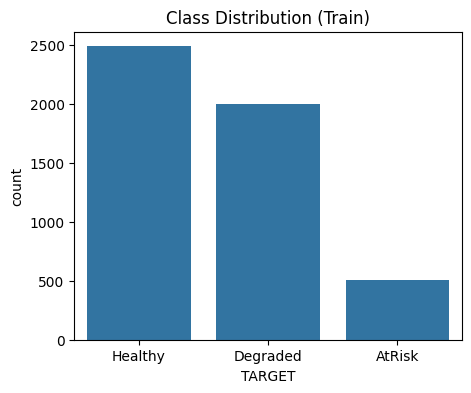

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x='TARGET', data=train_df, order=['Healthy','Degraded','AtRisk'])
plt.title("Class Distribution (Train)")
plt.show()


**Features & types**

In [6]:
id_cols = [c for c in train_df.columns if c.lower() in ('id','index') or train_df[c].nunique()==len(train_df)]
feature_cols = [c for c in train_df.columns if c not in id_cols+[target_col,'TARGET']]

X_all = train_df[feature_cols].copy()
y_all = train_df['TARGET'].copy()

X_test_raw = test_df[[c for c in feature_cols if c in test_df.columns]].copy()

num_cols = X_all.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print("Dropped ID-like cols:", id_cols)
print("Features:", len(feature_cols), "| Numeric:", len(num_cols), "| Categorical:", len(cat_cols))


Dropped ID-like cols: ['index']
Features: 30 | Numeric: 25 | Categorical: 5


**Small numeric plots**

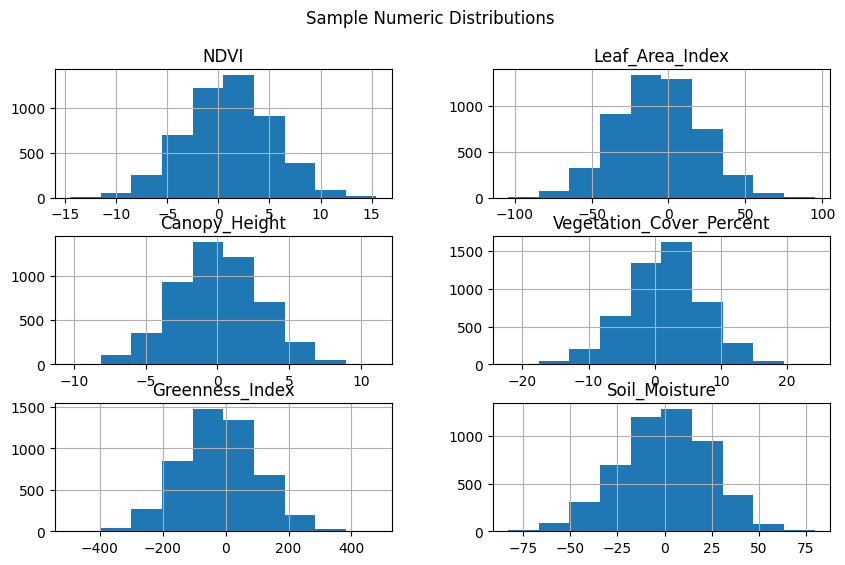

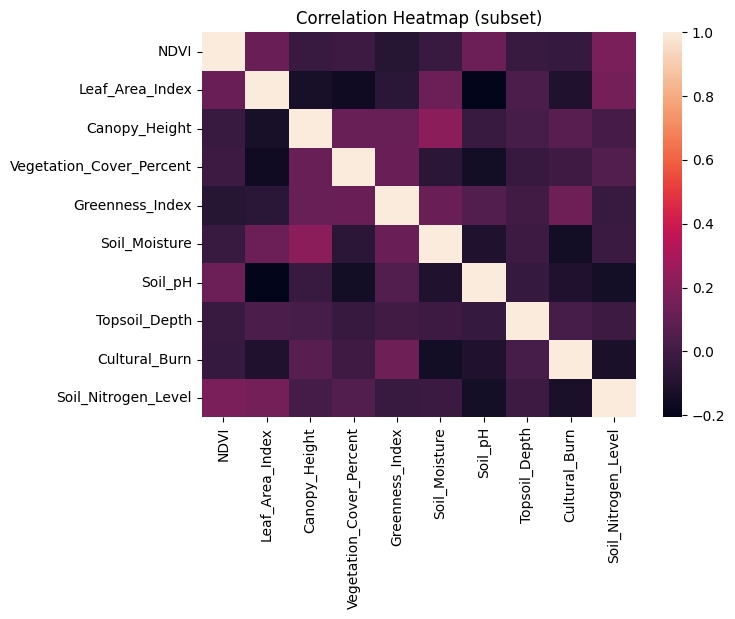

In [7]:
num_to_plot = num_cols[:6]
if num_to_plot:
    X_all[num_to_plot].hist(figsize=(10,6))
    plt.suptitle("Sample Numeric Distributions")
    plt.show()

if len(num_cols) >= 5:
    plt.figure(figsize=(7,5))
    sns.heatmap(X_all[num_cols[:10]].corr(), annot=False)
    plt.title("Correlation Heatmap (subset)")
    plt.show()


**Preprocessing pipeline**

In [8]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])
print("Preprocessor ready.")


Preprocessor ready.


**Transform & drop duplicates**

In [9]:
preprocessor.fit(X_all)
X_all_arr  = preprocessor.transform(X_all)
X_test_arr = preprocessor.transform(X_test_raw)

feat_names = []
if num_cols: feat_names += num_cols
if cat_cols:
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    feat_names += ohe.get_feature_names_out(cat_cols).tolist()

X_all_df  = pd.DataFrame(X_all_arr,  columns=feat_names, index=X_all.index)
X_test_df = pd.DataFrame(X_test_arr, columns=feat_names, index=X_test_raw.index)

# Drop duplicates
dup = X_all_df.duplicated().sum()
print("Duplicates:", dup)
if dup:
    keep = ~X_all_df.duplicated()
    X_all_df = X_all_df[keep]
    y_all = y_all[keep]


Duplicates: 50


**Split data**

In [10]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all_df, y_all, test_size=0.2, stratify=y_all, random_state=15
)
print("Train split:", X_tr.shape, "| Validation split:", X_val.shape)


Train split: (3960, 48) | Validation split: (990, 48)


**Oversample training split only**

In [11]:
df_tr = pd.concat([X_tr.reset_index(drop=True), y_tr.reset_index(drop=True).rename('label')], axis=1)
maj = df_tr['label'].value_counts().max()

parts = []
for cls, grp in df_tr.groupby('label'):
    if len(grp) < maj:
        parts.append(resample(grp, replace=True, n_samples=maj, random_state=42))
    else:
        parts.append(grp)
df_bal = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)

X_tr_bal = df_bal.drop(columns='label')
y_tr_bal = df_bal['label']
print("Balanced counts:\n", y_tr_bal.value_counts())


Balanced counts:
 label
Degraded    1975
AtRisk      1975
Healthy     1975
Name: count, dtype: int64


**Models & param grids**

In [12]:
models = {
    'knn': KNeighborsClassifier(),
    'nb' : GaussianNB(),
    'dt' : DecisionTreeClassifier(random_state=42),
    'rf' : RandomForestClassifier(random_state=42)
}
param_grids = {
    'knn': {'n_neighbors':[3,5,7], 'weights':['uniform','distance']},
    'nb' : {'var_smoothing':[1e-9, 1e-8]},
    'dt' : {'max_depth':[None,5,10], 'min_samples_split':[2,5]},
    'rf' : {'n_estimators':[100,200], 'max_depth':[None,10]}
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


**GridSearch + CV estimate**

In [13]:
best_models, grid_info = {}, {}

for name, est in models.items():
    grid = GridSearchCV(est, param_grids[name], cv=cv, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_tr_bal, y_tr_bal)
    best_models[name] = grid.best_estimator_

    cv_acc = cross_val_score(grid.best_estimator_, X_tr, y_tr, cv=cv, scoring='accuracy').mean()

    grid_info[name] = {
        'params': grid.best_params_,
        'cv_f1': grid.best_score_,
        'cv_acc': cv_acc
    }
    print(f"{name} best:", grid.best_params_, "| CV Acc (est):", round(cv_acc,4))


knn best: {'n_neighbors': 3, 'weights': 'distance'} | CV Acc (est): 0.8566
nb best: {'var_smoothing': 1e-08} | CV Acc (est): 0.1689
dt best: {'max_depth': None, 'min_samples_split': 2} | CV Acc (est): 0.7684
rf best: {'max_depth': None, 'n_estimators': 100} | CV Acc (est): 0.8924


**Evaluate on validation (Actual Acc)**

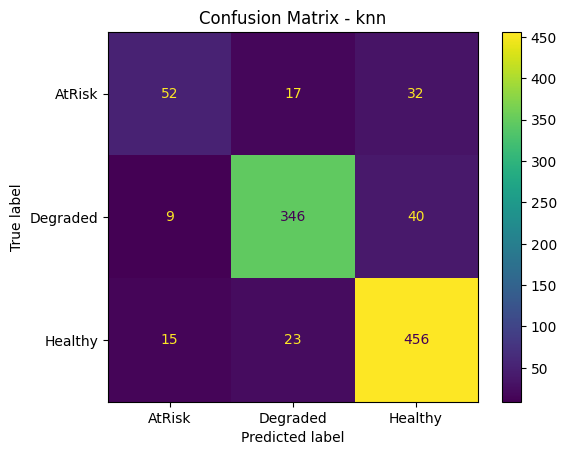

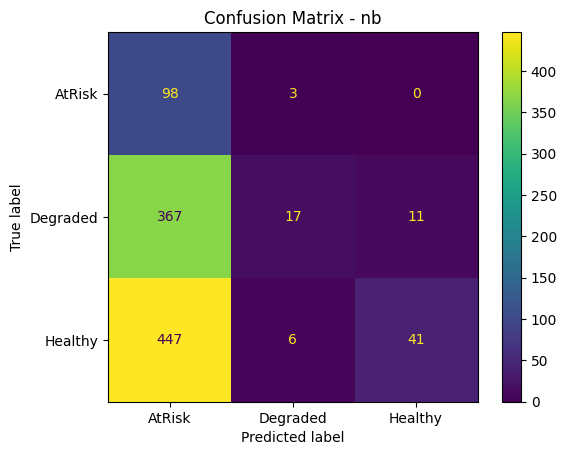

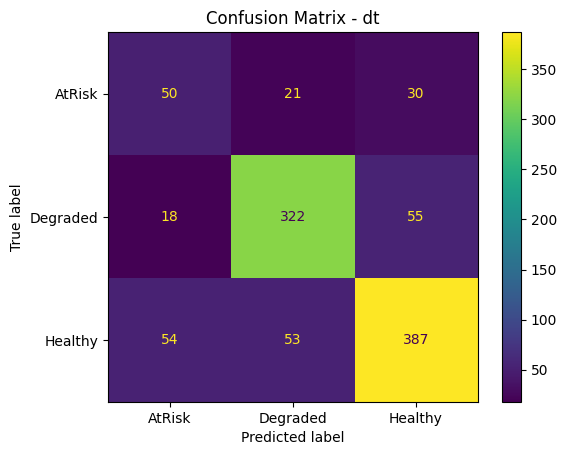

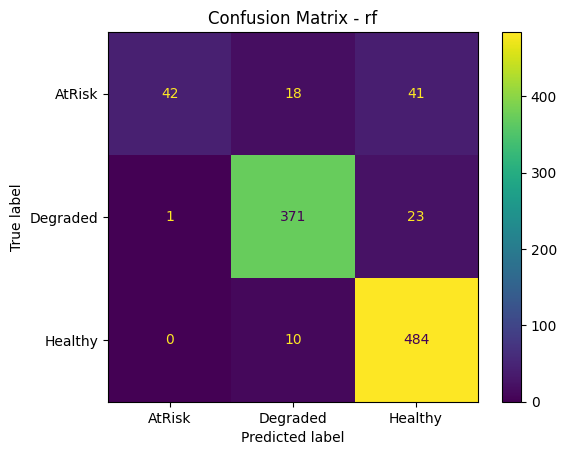

,actual_acc,f1_val,est_acc
knn,0.862626,0.788661,0.856566
nb,0.157576,0.141476,0.168939
dt,0.766667,0.687944,0.768434
rf,0.906061,0.815608,0.892424


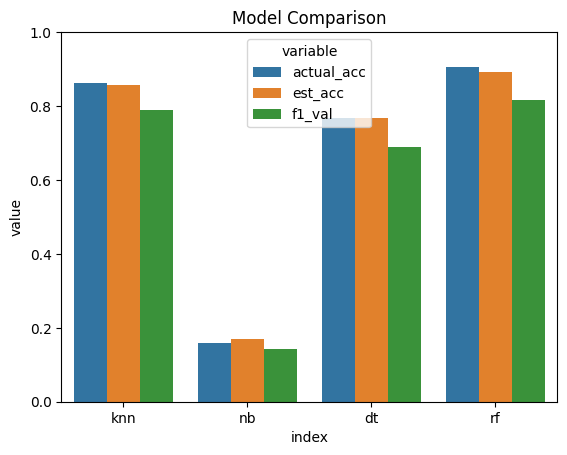

In [14]:
eval_summary = {}
for name, model in best_models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    f1m = f1_score(y_val, preds, average='macro')

    eval_summary[name] = {
        'actual_acc': acc,
        'f1_val': f1m,
        'est_acc': grid_info[name]['cv_acc']
    }

    ConfusionMatrixDisplay.from_predictions(y_val, preds)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

cmp_df = pd.DataFrame(eval_summary).T
display(cmp_df)

sns.barplot(data=cmp_df.reset_index().melt(id_vars='index', value_vars=['actual_acc','est_acc','f1_val']),
            x='index', y='value', hue='variable')
plt.title("Model Comparison")
plt.ylim(0,1)
plt.show()


**Retrain top 2 on full data**

In [15]:
top_two = sorted(eval_summary.items(), key=lambda kv: kv[1]['f1_val'], reverse=True)[:2]
top_two = [m for m,_ in top_two]
print("Top two:", top_two)

final_models = {}
for name in top_two:
    model = best_models[name]
    model.fit(X_all_df, y_all)
    final_models[name] = model

preds1 = final_models[top_two[0]].predict(X_test_df)
preds2 = final_models[top_two[1]].predict(X_test_df)


Top two: ['rf', 'knn']


**Save results**

In [16]:
test_id_col = next((c for c in test_df.columns if c.lower() in ('id','index')), None)
if test_id_col:
    idx_vals = test_df[test_id_col].astype(int).tolist()
else:
    idx_vals = list(range(len(train_df), len(train_df)+len(test_df)))

answers = pd.DataFrame({'index': idx_vals, 'Predict1': preds1, 'Predict2': preds2})
OUTFILE = "Answers_23107667.csv"
answers.to_csv(OUTFILE, index=False)
display(answers.head())

joblib.dump({
    'preprocessor': preprocessor,
    'best_models': best_models,
    'final_models': final_models,
    'eval_summary': eval_summary,
    'grid_info': grid_info
}, "models_and_info.joblib")

print("\n=== Key Results for Report ===")
for name, vals in eval_summary.items():
    print(f"{name}: Actual Acc={vals['actual_acc']:.3f}, Estimated Acc={vals['est_acc']:.3f}, F1={vals['f1_val']:.3f}")


,index,Predict1,Predict2
0,5000,Degraded,Degraded
1,5001,Degraded,Degraded
2,5002,Healthy,Healthy
3,5003,Healthy,Healthy
4,5004,Healthy,Healthy



=== Key Results for Report ===
knn: Actual Acc=0.863, Estimated Acc=0.857, F1=0.789
nb: Actual Acc=0.158, Estimated Acc=0.169, F1=0.141
dt: Actual Acc=0.767, Estimated Acc=0.768, F1=0.688
rf: Actual Acc=0.906, Estimated Acc=0.892, F1=0.816
